In [262]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/Users/petertroitsky/Desktop/Датасет соц сети (2).csv')

# базовая информация

print('Размер датасета:', df.shape)
print('\nПризнаки:', df.columns.tolist())

# пропуски

missing = (
    df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print('\nПроцент пропусков:\n', missing)

# очистка данных

df = df.drop(columns=['csat_score'])
df = df.drop_duplicates(subset='id_client')
df = df.dropna(subset=['gender_cd'])

# баланс целевой переменной

print(
    '\nРаспределение review_mark:\n',
    df['review_mark'].value_counts(normalize=True) * 100
)

# проверка кардинальности категориальных признаков

cat_cols = [
    'company',
    'product',
    'review_source',
    'segment_name',
    'age_segment',
    'gender_cd'
]

for col in cat_cols:
    print(f'\n{col}: {df[col].nunique()} уникальных значений')

# итоговый размер

print('\nРазмер после очистки:', df.shape)

# сохранение датасета

df.to_csv('dataset_clean.csv', index=False)

Размер датасета: (56820, 25)

Признаки: ['review_dttm', 'finish_dttm', 'id_client', 'company', 'review_mark', 'review_emotion', 'review_source', 'business_line', 'product', 'reason', 'review_theme', 'subtheme', 'review_text', 'solution_flg', 'gender_cd', 'education_level_cd', 'marital_status_cd', 'children_cnt', 'citizenship_country', 'segment_name', 'subscription_important_flg', 'new_flg', 'influencer_flg', 'age_segment', 'csat_score']

Процент пропусков:
 csat_score                    94.003872
education_level_cd            56.015488
marital_status_cd             33.164379
children_cnt                  23.720521
influencer_flg                23.252376
new_flg                       23.252376
subscription_important_flg    23.252376
segment_name                  23.252376
age_segment                   18.949314
review_text                    3.690602
gender_cd                      0.571982
citizenship_country            0.212953
finish_dttm                    0.165435
review_theme      

Размер датасета: (39988, 24)


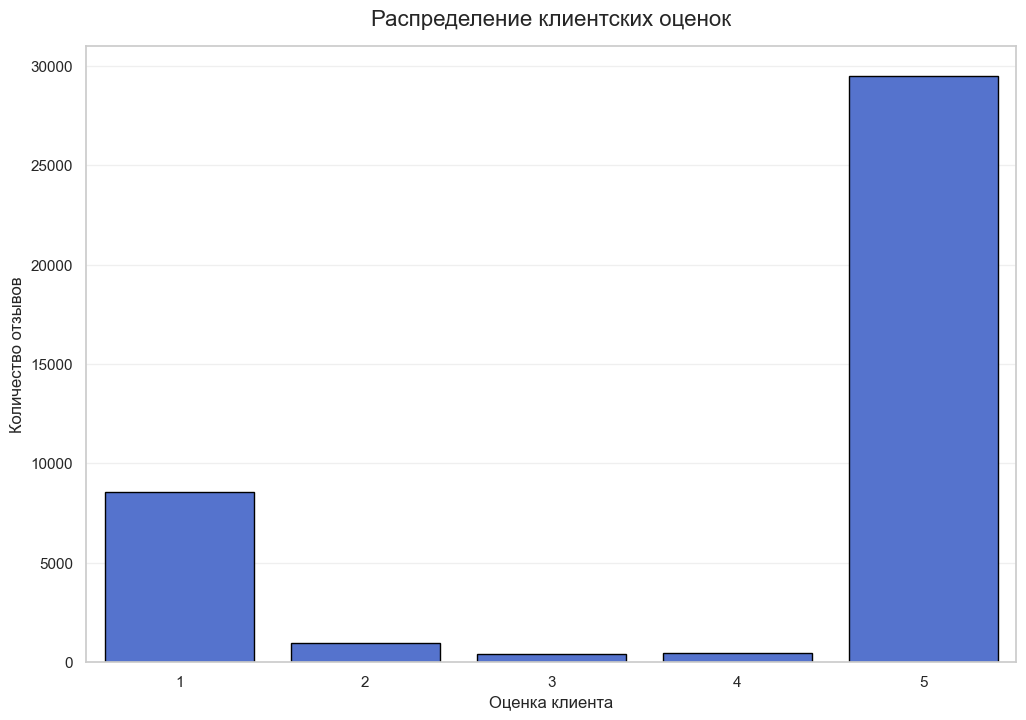

Доля "не указано" в solution_flg: 85.36%


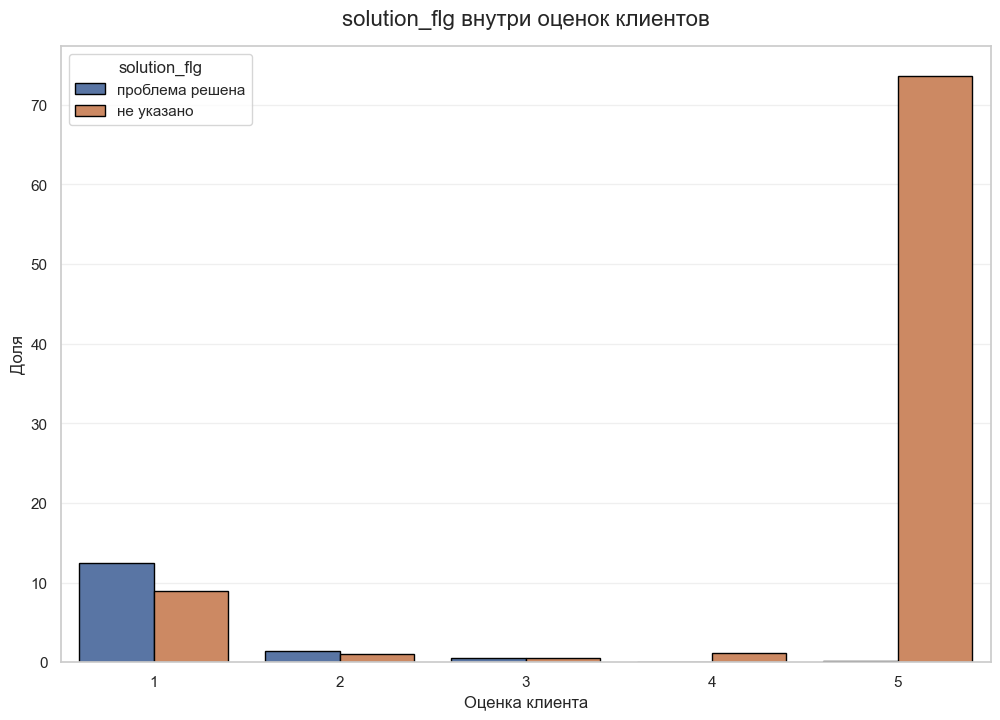

Доля оценок (%):
 review_mark
1    21.47
2     2.44
3     1.09
4     1.22
5    73.78
Name: proportion, dtype: float64
Средняя оценка: 4.03
Медианная оценка: 5.0


In [263]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# используем уже очищенный датасет из прошлого шага
df = pd.read_csv('dataset_clean.csv')

# оставляем только корректные оценки

df = df[
    df['review_mark'].isin(['1', '2', '3', '4', '5'])
].copy()

df['review_mark'] = df['review_mark'].astype(int)

print('Размер датасета:', df.shape)

# распределение оценок

fig, ax = plt.subplots(figsize=(12, 8))

sns.countplot(
    data=df,
    x='review_mark',
    color='royalblue',
    edgecolor='black',
    ax=ax
)

ax.set_title('Распределение клиентских оценок', fontsize=16, pad=15)
ax.set_xlabel('Оценка клиента')
ax.set_ylabel('Количество отзывов')

ax.grid(axis='y', alpha=0.3)

plt.show()

# доля "не указано" в solution_flg

missing_solution = (df['solution_flg'] == 'не указано').mean() * 100

print(f'Доля "не указано" в solution_flg: {missing_solution:.2f}%')

# распределение solution_flg внутри review_mark

df['solution_flg'] = df['solution_flg'].astype(str)

fig, ax = plt.subplots(figsize=(12, 8))

sns.countplot(
    data=df,
    x='review_mark',
    hue='solution_flg',
    edgecolor='black',
    ax=ax,
    stat='percent'
)

ax.set_title('solution_flg внутри оценок клиентов', fontsize=16, pad=15)
ax.set_xlabel('Оценка клиента')
ax.set_ylabel('Доля')

ax.set_xticks([0, 1, 2, 3, 4])

ax.grid(axis='y', alpha=0.3)

plt.show()

# распределение оценок в процентах

review_dist = (
    df['review_mark']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

print('Доля оценок (%):\n', review_dist.round(2))

print('Средняя оценка:', round(df['review_mark'].mean(), 2))
print('Медианная оценка:', df['review_mark'].median())

# сохраняем промежуточный датасет

df.to_csv('dataset_step2.csv', index=False)

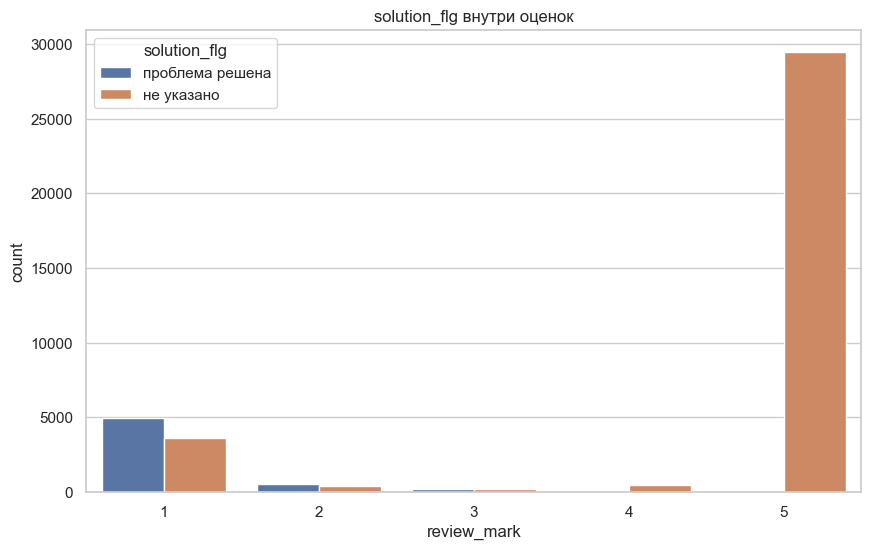

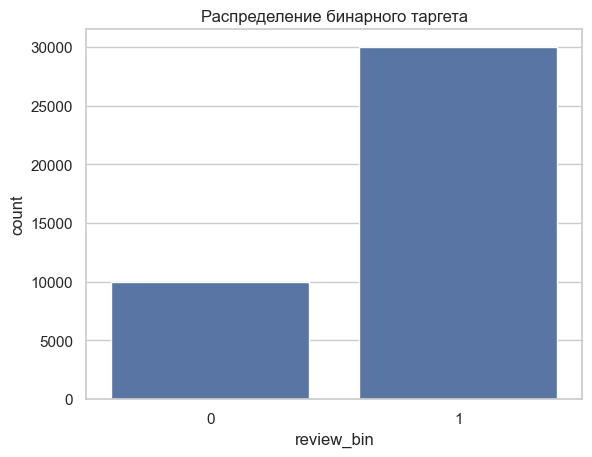

финальный размер: (28266, 25)


In [266]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('dataset_step2.csv')

# оставляем только валидные оценки

df = df[
    df['review_mark'].isin([1, 2, 3, 4, 5])
].copy()

df['review_mark'] = df['review_mark'].astype(int)

# анализ связи с solution_flg

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='review_mark',
    hue='solution_flg'
)

plt.title('solution_flg внутри оценок')
plt.show()

# бинаризация таргета

data = df.copy()

data['review_bin'] = 0

data.loc[
    data['review_mark'].isin([1, 2, 3]),
    'review_bin'
] = 0

data.loc[
    data['review_mark'].isin([4, 5]),
    'review_bin'
] = 1

# распределение бина

sns.countplot(
    data=data,
    x='review_bin'
)

plt.title('Распределение бинарного таргета')
plt.show()

# очистка пропусков

cols_to_dropna = [
    'gender_cd',
    'segment_name',
    'age_segment',
    'company',
    'product',
    'review_source',
    'influencer_flg'
]

data = data.dropna(subset=cols_to_dropna)

# фильтр неизвестного возраста
data = data[data['age_segment'] != 'Не определен']

print('финальный размер:', data.shape)

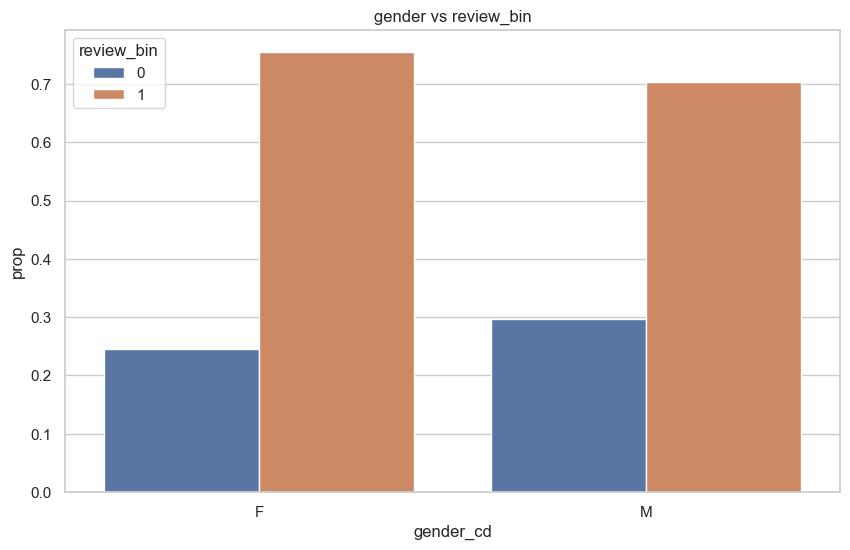

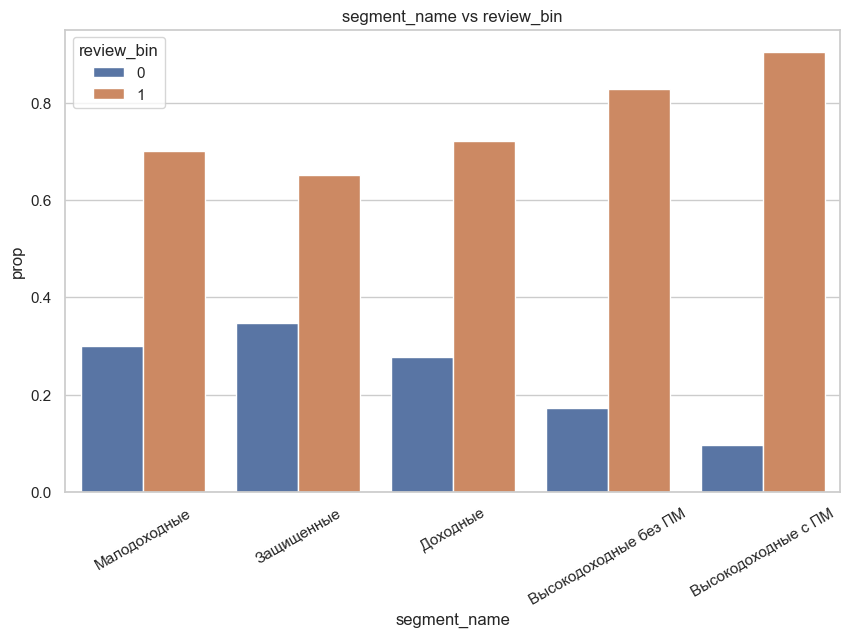

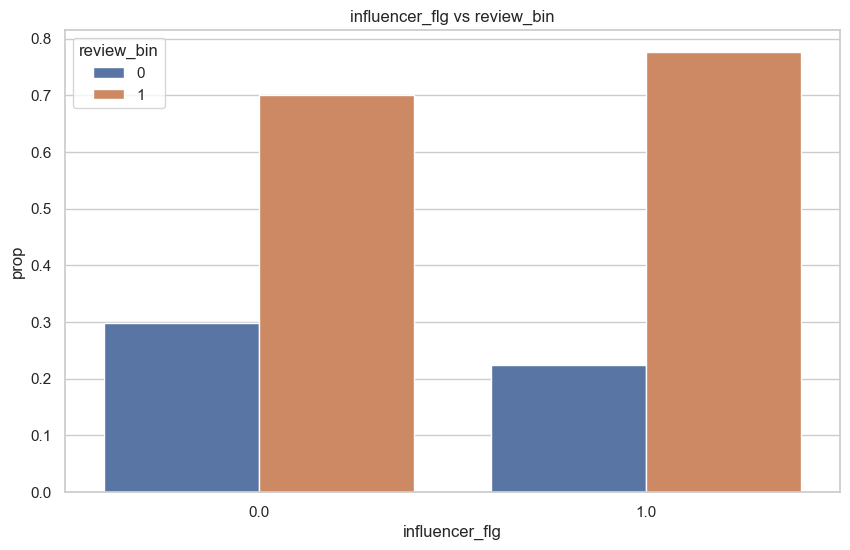

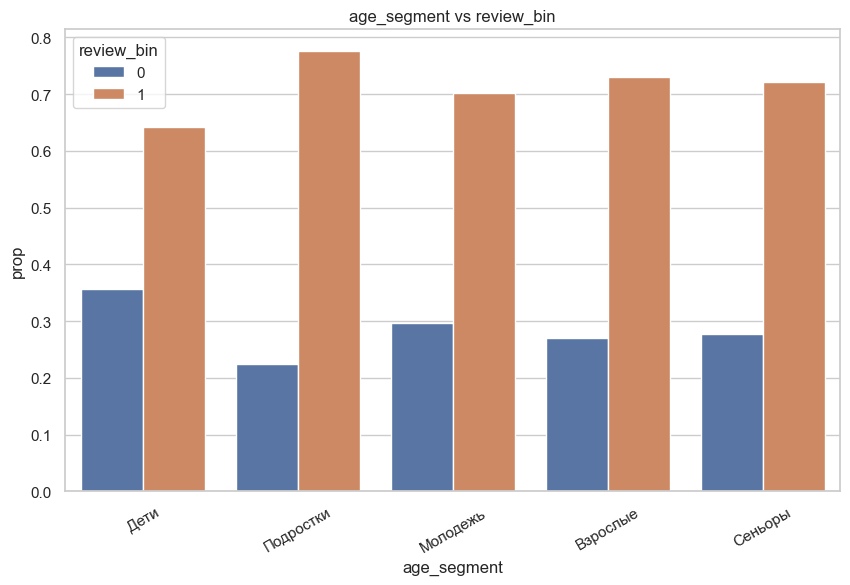

In [267]:
df = data.copy()

# распределение review_bin по полу

fig, ax = plt.subplots(figsize=(10, 6))

df_plot_gen = (
    df.groupby('gender_cd')['review_bin']
    .value_counts(normalize=True)
    .reset_index(name='prop')
)

sns.barplot(
    data=df_plot_gen,
    x='gender_cd',
    y='prop',
    hue='review_bin',
    ax=ax
)

plt.title('gender vs review_bin')
plt.show()

# сегментные признаки

segment_order = [
    'Малодоходные',
    'Защищенные',
    'Доходные',
    'Высокодоходные без ПМ',
    'Высокодоходные с ПМ'
]

age_order = [
    'Дети',
    'Подростки',
    'Молодежь',
    'Взрослые',
    'Сеньоры'
]

# segment_name

fig, ax = plt.subplots(figsize=(10, 6))

df_plot_seg = (
    df.groupby('segment_name')['review_bin']
    .value_counts(normalize=True)
    .reset_index(name='prop')
)

sns.barplot(
    data=df_plot_seg,
    x='segment_name',
    y='prop',
    hue='review_bin',
    order=segment_order,
    ax=ax
)

plt.title('segment_name vs review_bin')
plt.xticks(rotation=30)
plt.show()


fig, ax = plt.subplots(figsize=(10, 6))

df_plot_inf = (
    df.groupby('influencer_flg')['review_bin']
    .value_counts(normalize=True)
    .reset_index(name='prop')
)

sns.barplot(
    data=df_plot_inf,
    x='influencer_flg',
    y='prop',
    hue='review_bin',
    ax=ax
)

plt.title('influencer_flg vs review_bin')
plt.show()

# age_segment

fig, ax = plt.subplots(figsize=(10, 6))

df_plot_age = (
    df.groupby('age_segment')['review_bin']
    .value_counts(normalize=True)
    .reset_index(name='prop')
)

sns.barplot(
    data=df_plot_age,
    x='age_segment',
    y='prop',
    hue='review_bin',
    order=age_order,
    ax=ax
)

plt.title('age_segment vs review_bin')
plt.xticks(rotation=30)
plt.show()

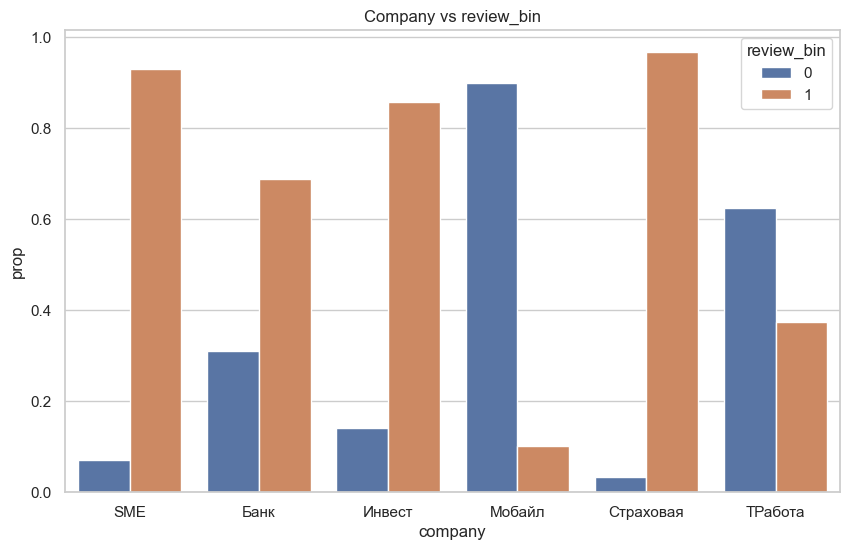

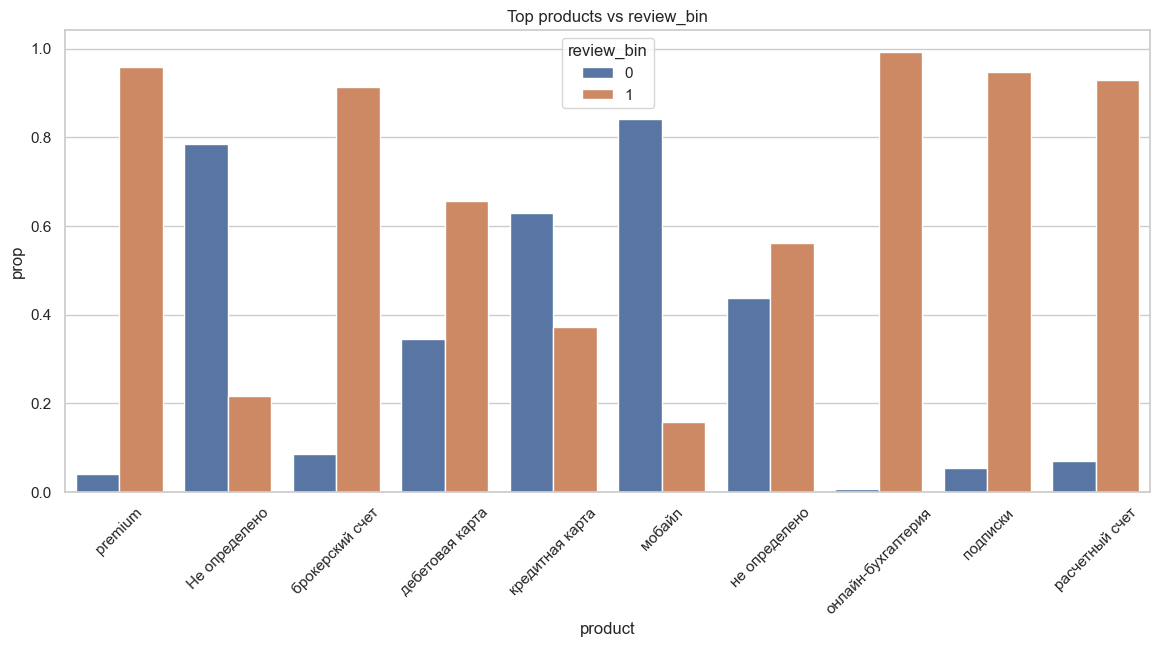

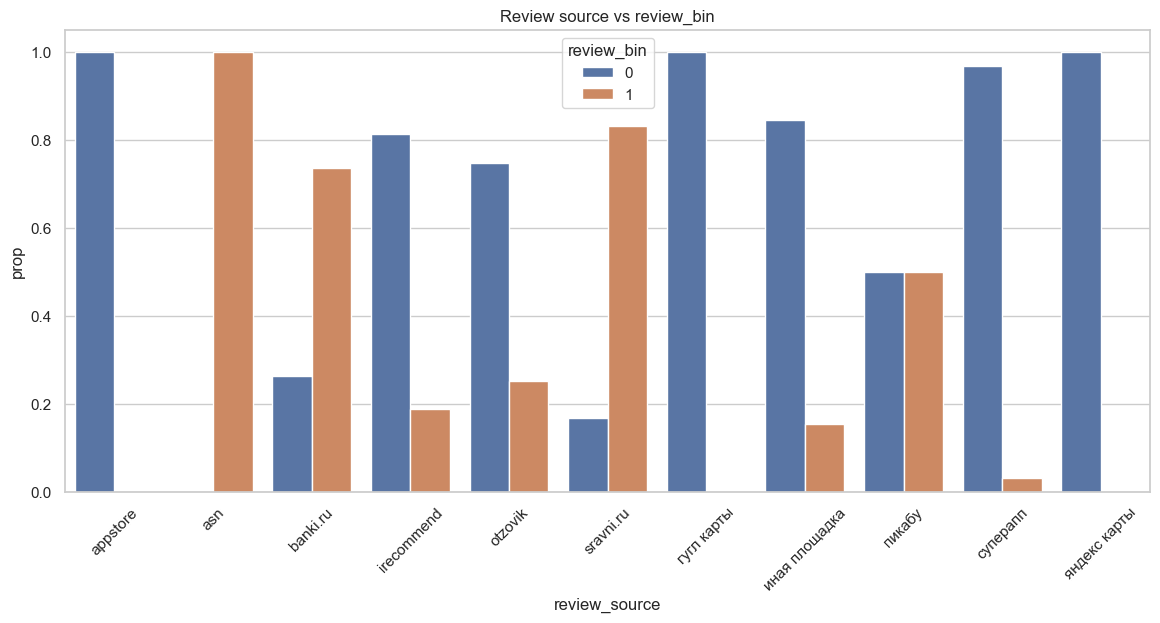

In [268]:
# работаем с копией датасета

df = data.copy()

# анализ продуктовых признаков

# -------------------------
# company
# -------------------------

fig, ax = plt.subplots(figsize=(10, 6))

df_plot_com = (
    df.groupby('company')['review_bin']
    .value_counts(normalize=True)
    .reset_index(name='prop')
)

sns.barplot(
    data=df_plot_com,
    x='company',
    y='prop',
    hue='review_bin',
    ax=ax
)

plt.title('Company vs review_bin')
plt.show()

# -------------------------
# product очистка
# -------------------------

df = df[df['product'] != 'нет']

valid_products = df['product'].value_counts()
df = df[df['product'].isin(valid_products[valid_products >= 50].index)]

# распределение review_bin по product

df_plot_prod = (
    df.groupby('product')['review_bin']
    .value_counts(normalize=True)
    .reset_index(name='prop')
)

top_products = df['product'].value_counts().head(10).index

fig, ax = plt.subplots(figsize=(14, 6))

sns.barplot(
    data=df_plot_prod[df_plot_prod['product'].isin(top_products)],
    x='product',
    y='prop',
    hue='review_bin',
    ax=ax
)

plt.xticks(rotation=45)
plt.title('Top products vs review_bin')
plt.show()

# -------------------------
# review_source
# -------------------------

fig, ax = plt.subplots(figsize=(14, 6))

df_plot_review = (
    df.groupby('review_source')['review_bin']
    .value_counts(normalize=True)
    .reset_index(name='prop')
)

sns.barplot(
    data=df_plot_review,
    x='review_source',
    y='prop',
    hue='review_bin',
    ax=ax
)

plt.xticks(rotation=45)
plt.title('Review source vs review_bin')
plt.show()

#заметим, что у нас соотношения 0/1 на продуктовых признаков намного более разняться при рассмотрении разных значений этих признаков.

#исходя из этого формулируем гипотезу: вероятность положительного клиентского опыта в большей степени определяется особенностями продукта и типа обращения, чем характеристиками самого клиента.

In [269]:
#пересохраним датасет, чтобы загрузить его  в дальнейший ноутбук

data3 = df.copy()

data3.to_csv('data3.csv', index=False)